In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
from collections import Counter
pd.set_option('display.precision', 3)
from pandas import read_csv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn import preprocessing
from pandas.plotting import scatter_matrix
from scipy.stats import boxcox
from statsmodels.genmod.generalized_linear_model import GLM
from sklearn.model_selection import train_test_split

In [23]:
wifi = pd.read_csv('../data/raw/train_nt.csv', header=0, delimiter=';')
X_test_nolabels = pd.read_csv('../data/raw/test_nolabels_nt.csv', header=0, delimiter=';')
wifi.shape

(12888, 262)

In [24]:
wifi.head()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
0,0,0,-5703,-88,-88,0,0,4,5,7,...,-13,6,-13,-2,-8,3,-12,1,-12,9
1,1,0,1835,-91,-88,0,0,-10,4,-7,...,-7,-11,-9,-18,-7,-8,-8,-8,-10,9
2,2,0,4,-86,-87,0,0,5,14,5,...,10,7,16,7,13,11,16,11,13,9
3,3,52464,1259,-81,-71,0,0,-1,12,1,...,13,-7,14,-6,17,-6,16,-7,16,2
4,4,0,900,-82,-76,0,0,9,2,9,...,6,14,4,16,7,14,7,14,2,2


In [25]:
wifi.describe()

,ID,seq_ctrl,aoa,rssi1,rssi2,I0_1,Q0_1,I1_1,Q1_1,I2_1,...,Q59_2,I60_2,Q60_2,I61_2,Q61_2,I62_2,Q62_2,I63_2,Q63_2,position
count,12888.000,12888.000,12888.000,12888.000,12888.000,12888.0,12888.0,12888.000,12888.000,12888.000,...,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000,12888.000
mean,6443.500,16008.410,15.017,-78.052,-77.952,0.0,0.0,-0.406,-0.478,-0.500,...,-0.402,-0.355,-0.296,-0.328,-0.295,-0.311,-0.269,-0.241,-0.363,4.493
std,3720.589,19829.509,3087.311,6.805,8.349,0.0,0.0,10.209,10.123,10.416,...,10.549,10.407,10.520,11.013,11.160,11.075,11.248,11.018,11.118,2.871
min,0.000,0.000,-8703.000,-97.000,-94.000,0.0,0.0,-25.000,-26.000,-24.000,...,-25.000,-25.000,-26.000,-32.000,-38.000,-25.000,-26.000,-27.000,-31.000,0.000
25%,3221.750,0.000,-1751.000,-83.000,-84.000,0.0,0.0,-10.000,-10.000,-10.000,...,-10.000,-10.000,-10.000,-10.000,-10.000,-11.000,-11.000,-10.000,-11.000,2.000
50%,6443.500,5464.000,-30.000,-80.000,-80.000,0.0,0.0,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.000
75%,9665.250,29424.000,1798.000,-74.000,-71.000,0.0,0.0,9.000,9.000,9.000,...,9.000,9.000,9.000,10.000,10.000,10.000,10.000,10.000,10.000,7.000
max,12887.000,65520.000,8915.000,-58.000,-58.000,0.0,0.0,25.000,25.000,23.000,...,23.000,29.000,23.000,33.000,35.000,25.000,25.000,26.000,26.000,9.000


In [26]:
wifi.dtypes

ID          int64
seq_ctrl    int64
aoa         int64
rssi1       int64
rssi2       int64
            ...  
I62_2       int64
Q62_2       int64
I63_2       int64
Q63_2       int64
position    int64
Length: 262, dtype: object

In [27]:
print(wifi.isnull().values.any()) # no hay supuestos NA
print((wifi == " ").sum().sum())
print((wifi == "").sum().sum())

False
0
0


Si nos fijamos en la descripción del dataset, seq_ctrl: uint16 sequence numbers. Por lo tanto, seq_ctrl [0,2^16 -1] = [0, 65535].
Los últimos números se guardan para detectar errores?


In [28]:
print((wifi["seq_ctrl"] >= 65520).sum().sum()) #posibles errores

3


In [29]:
print(wifi["position"].value_counts())

position
1    1488
5    1397
8    1312
7    1278
9    1273
4    1249
3    1237
6    1230
2    1224
0    1200
Name: count, dtype: int64


array([<Axes: title={'center': 'seq_ctrl'}>], dtype=object)

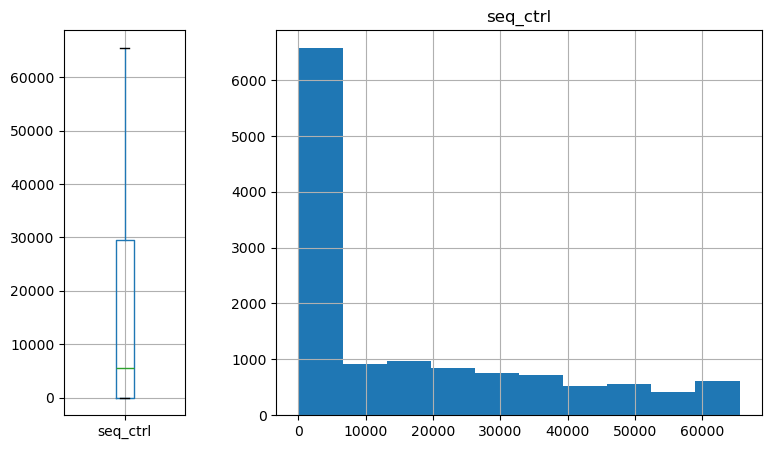

In [30]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='seq_ctrl',ax=axes[0])
wifi.hist(column='seq_ctrl', ax=axes[1])

array([<Axes: title={'center': 'aoa'}>], dtype=object)

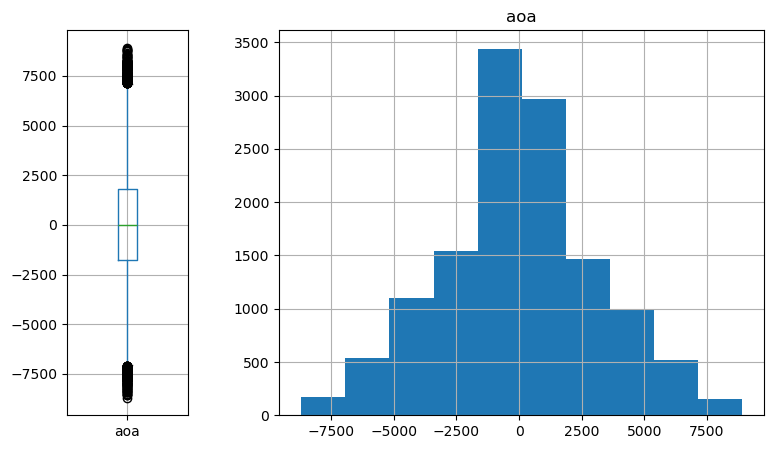

In [31]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='aoa',ax=axes[0])
wifi.hist(column='aoa', ax=axes[1])

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

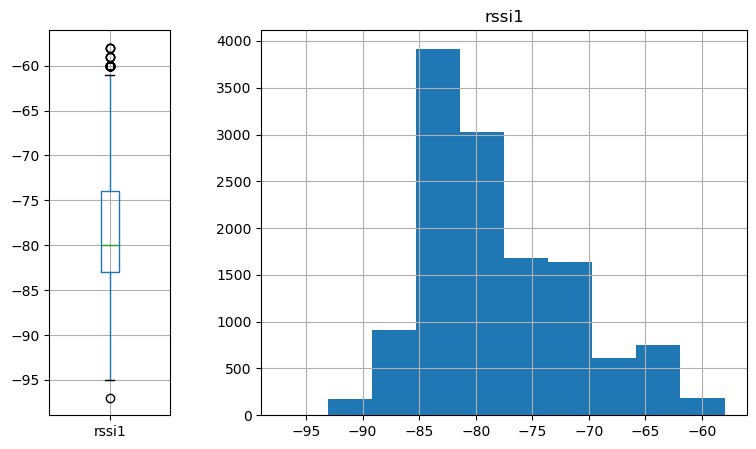

In [32]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='rssi1',ax=axes[0])
wifi.hist(column='rssi1', ax=axes[1])

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

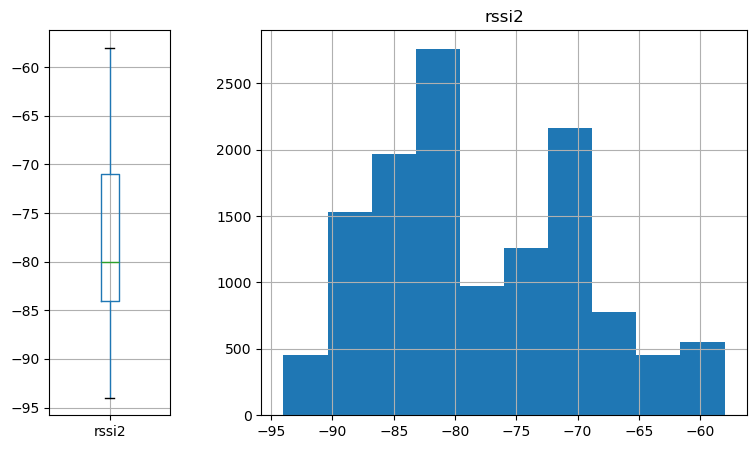

In [33]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
wifi.boxplot(column='rssi2',ax=axes[0])
wifi.hist(column='rssi2', ax=axes[1])

In [34]:
y, X = wifi['position'], wifi.drop('position', axis=1)

# NUEVAS VARIABLES

In [35]:
def create_magnitude_features(X):
    """
    Crea features de magnitud a partir de componentes I/Q
    y devuelve el dataset reducido.

    Parameters:
    - X: DataFrame con columnas I{n}_{antena}, Q{n}_{antena}

    Returns:
    - X_new: DataFrame con features originales + magnitudes
    """

    features = ['seq_ctrl', 'aoa', 'rssi1', 'rssi2']
    magnitude = []

    for antena in [1, 2]:
        for n in range(64):

            i_col = f"I{n}_{antena}"
            q_col = f"Q{n}_{antena}"
            mag_col = f"mag{n}_{antena}"

            X[mag_col] = np.sqrt(X[i_col]**2 + X[q_col]**2)
            magnitude.append(mag_col)

    X_new = X[features + magnitude]

    return X_new

X_new = create_magnitude_features(X)
X_test_nolabels = create_magnitude_features(X_test_nolabels)

X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)


C:\Users\dijor\AppData\Local\Temp\ipykernel_5284\294283912.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[mag_col] = np.sqrt(X[i_col]**2 + X[q_col]**2)
C:\Users\dijor\AppData\Local\Temp\ipykernel_5284\294283912.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[mag_col] = np.sqrt(X[i_col]**2 + X[q_col]**2)
C:\Users\dijor\AppData\Local\Temp\ipykernel_5284\294283912.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  C

In [36]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(10310, 132) (10310,)
(2578, 132) (2578,)


# OUTLIER DETECTION  (seq_ctrl, aoa, rssi1, rssi2) 

In [37]:
def remove_outliers_iqr(df, feature_cols):
    """Remove outliers using IQR method on each feature column."""
    for col in feature_cols:
        if df[col].dtype in ["int64", "float64"]:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

## seq_ctrl
Variable que no modificaremos (no sirve?)

array([<Axes: title={'center': 'seq_ctrl'}>], dtype=object)

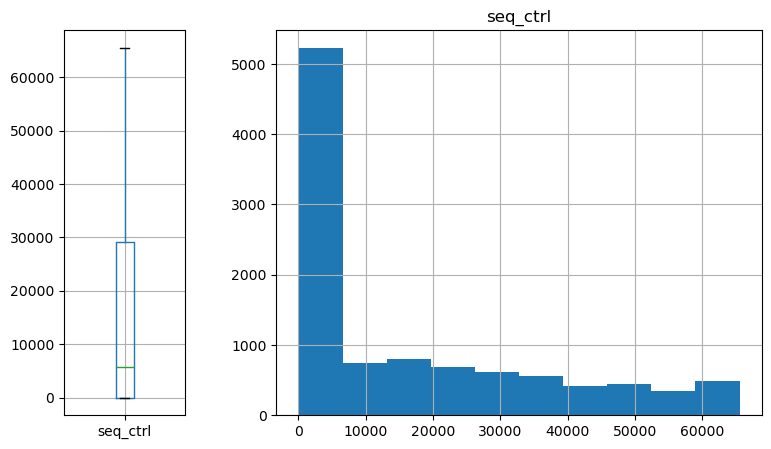

In [38]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train.boxplot(column='seq_ctrl',ax=axes[0])
X_train.hist(column='seq_ctrl', ax=axes[1])

## aoa

array([<Axes: title={'center': 'aoa'}>], dtype=object)

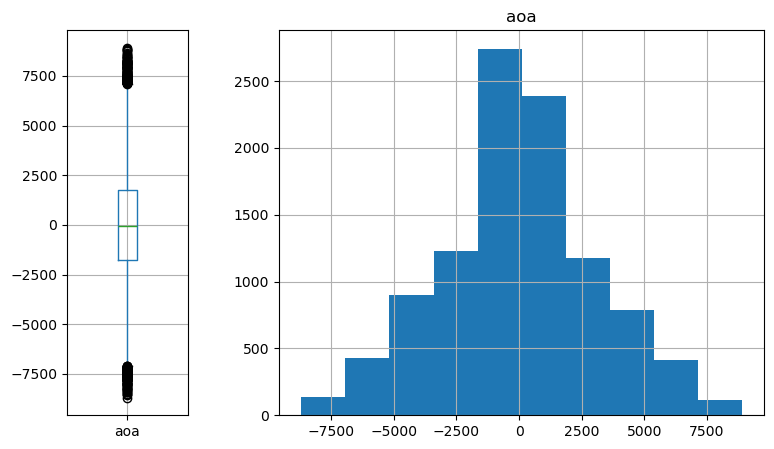

In [39]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train.boxplot(column='aoa',ax=axes[0])
X_train.hist(column='aoa', ax=axes[1])

In [40]:
X_train_filtered = remove_outliers_iqr(X_train, ["aoa"])

array([<Axes: title={'center': 'aoa'}>], dtype=object)

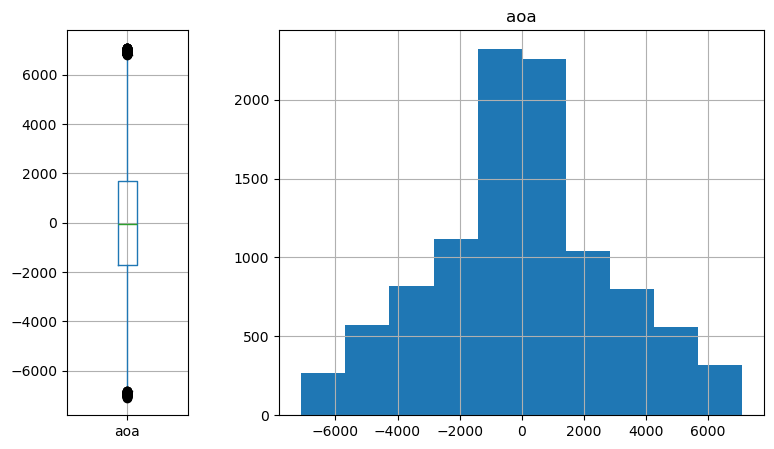

In [41]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.boxplot(column='aoa',ax=axes[0])
X_train_filtered.hist(column='aoa', ax=axes[1])

In [42]:
y_train_filtered = y_train[X_train_filtered.index]

In [43]:
X_train_filtered.shape, y_train_filtered.shape

((10074, 132), (10074,))

## rssi1

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

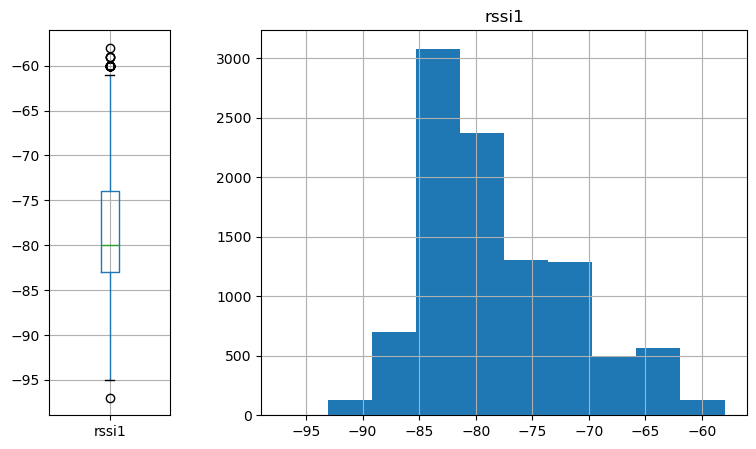

In [44]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.boxplot(column='rssi1',ax=axes[0])
X_train_filtered.hist(column='rssi1', ax=axes[1])

In [45]:
X_train_filtered = remove_outliers_iqr(X_train_filtered, ["rssi1"])

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

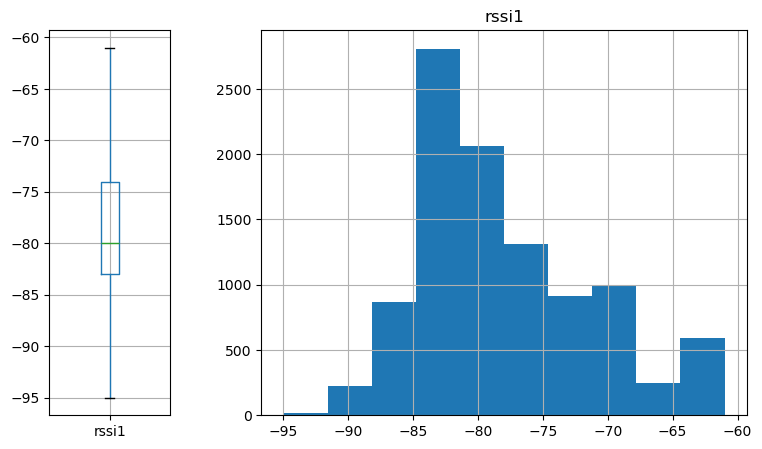

In [46]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.boxplot(column='rssi1',ax=axes[0])
X_train_filtered.hist(column='rssi1', ax=axes[1])

In [47]:
y_train_filtered = y_train_filtered[X_train_filtered.index]

In [48]:
X_train_filtered.shape, y_train_filtered.shape

((10045, 132), (10045,))

## rssi2

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

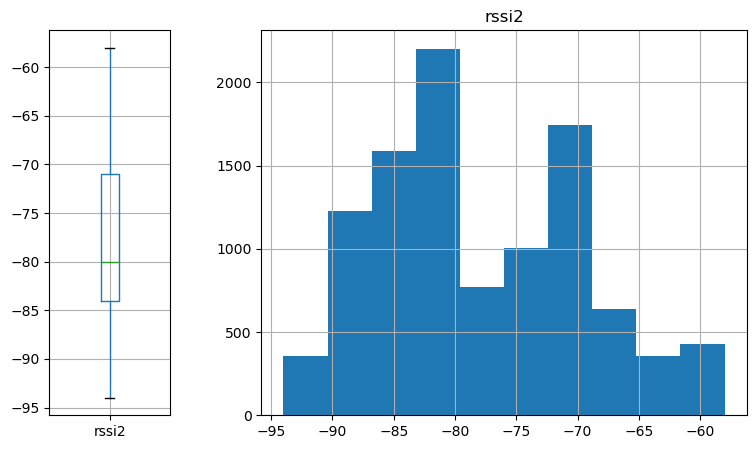

In [49]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.boxplot(column='rssi2',ax=axes[0])
X_train.hist(column='rssi2', ax=axes[1])

In [50]:
X_train_filtered = remove_outliers_iqr(X_train_filtered, ["rssi2"])

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

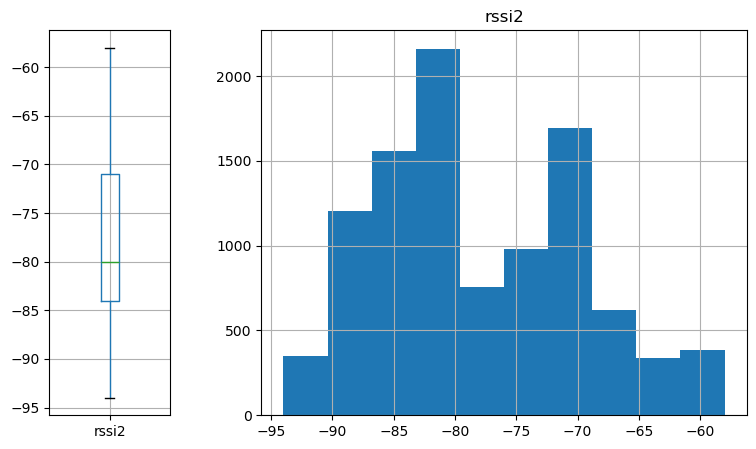

In [51]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.boxplot(column='rssi2',ax=axes[0])
X_train_filtered.hist(column='rssi2', ax=axes[1])

In [52]:

y_train_filtered = y_train_filtered[X_train_filtered.index]


print(X_train_filtered.shape, y_train_filtered.shape)


(10045, 132) (10045,)


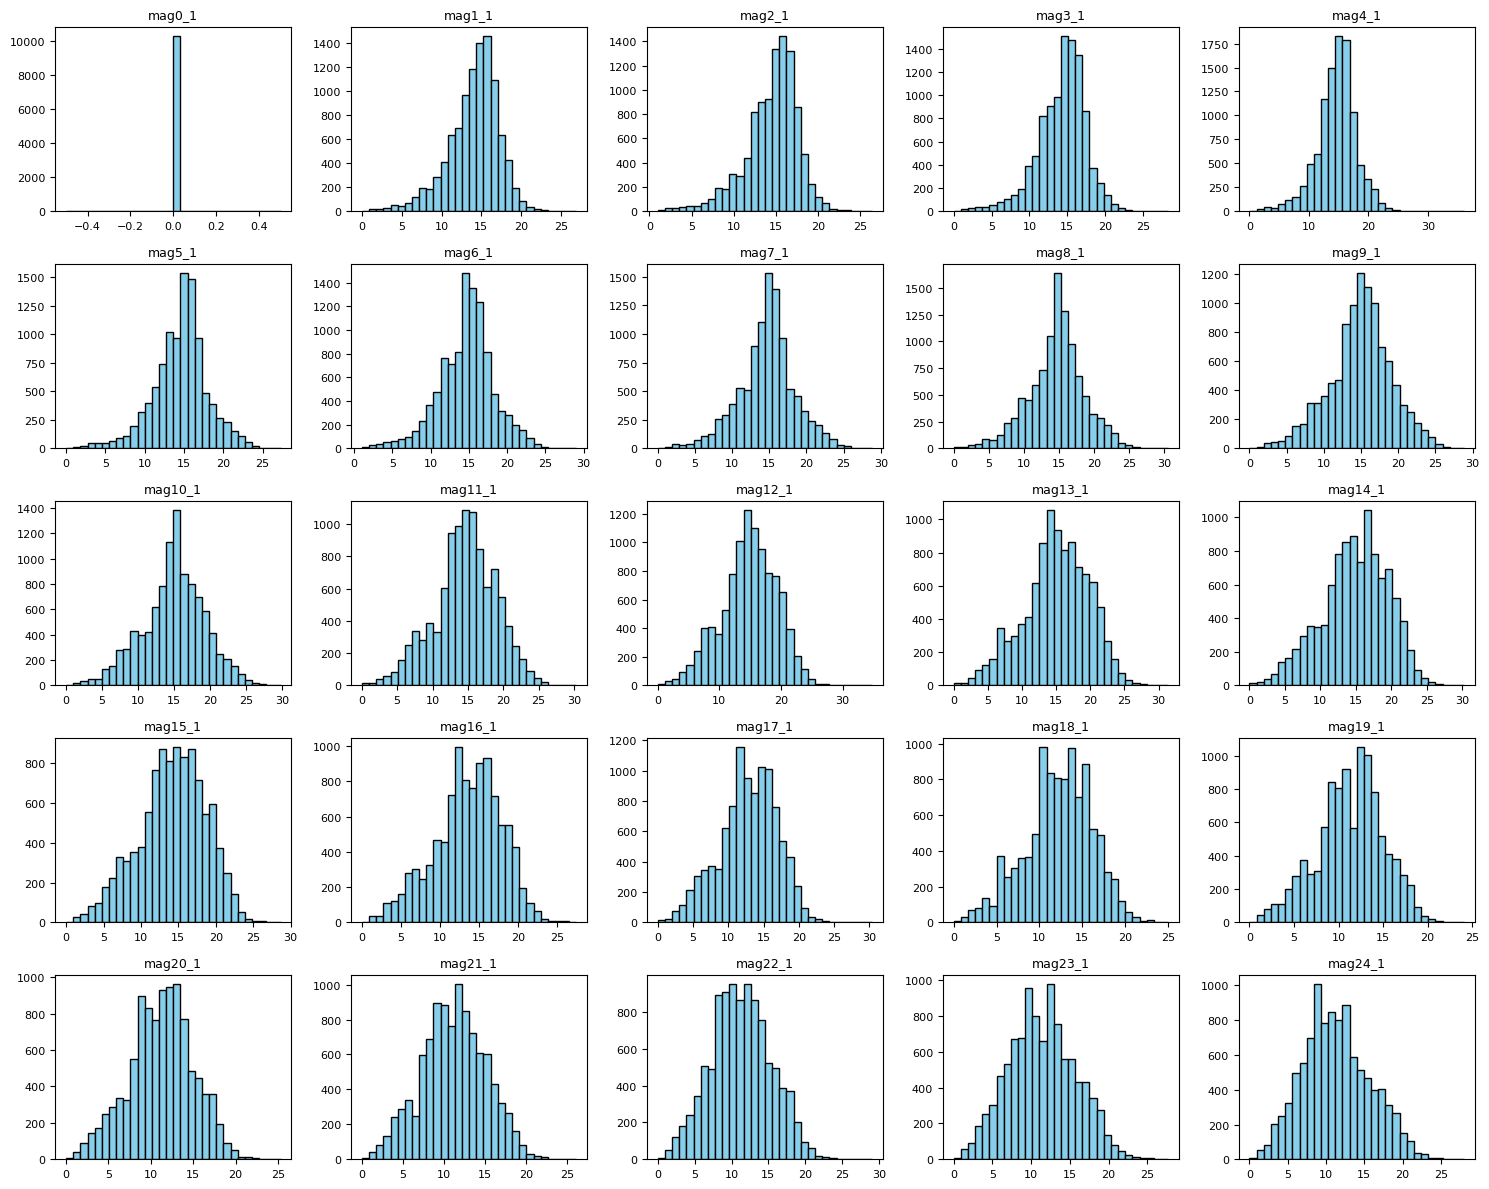

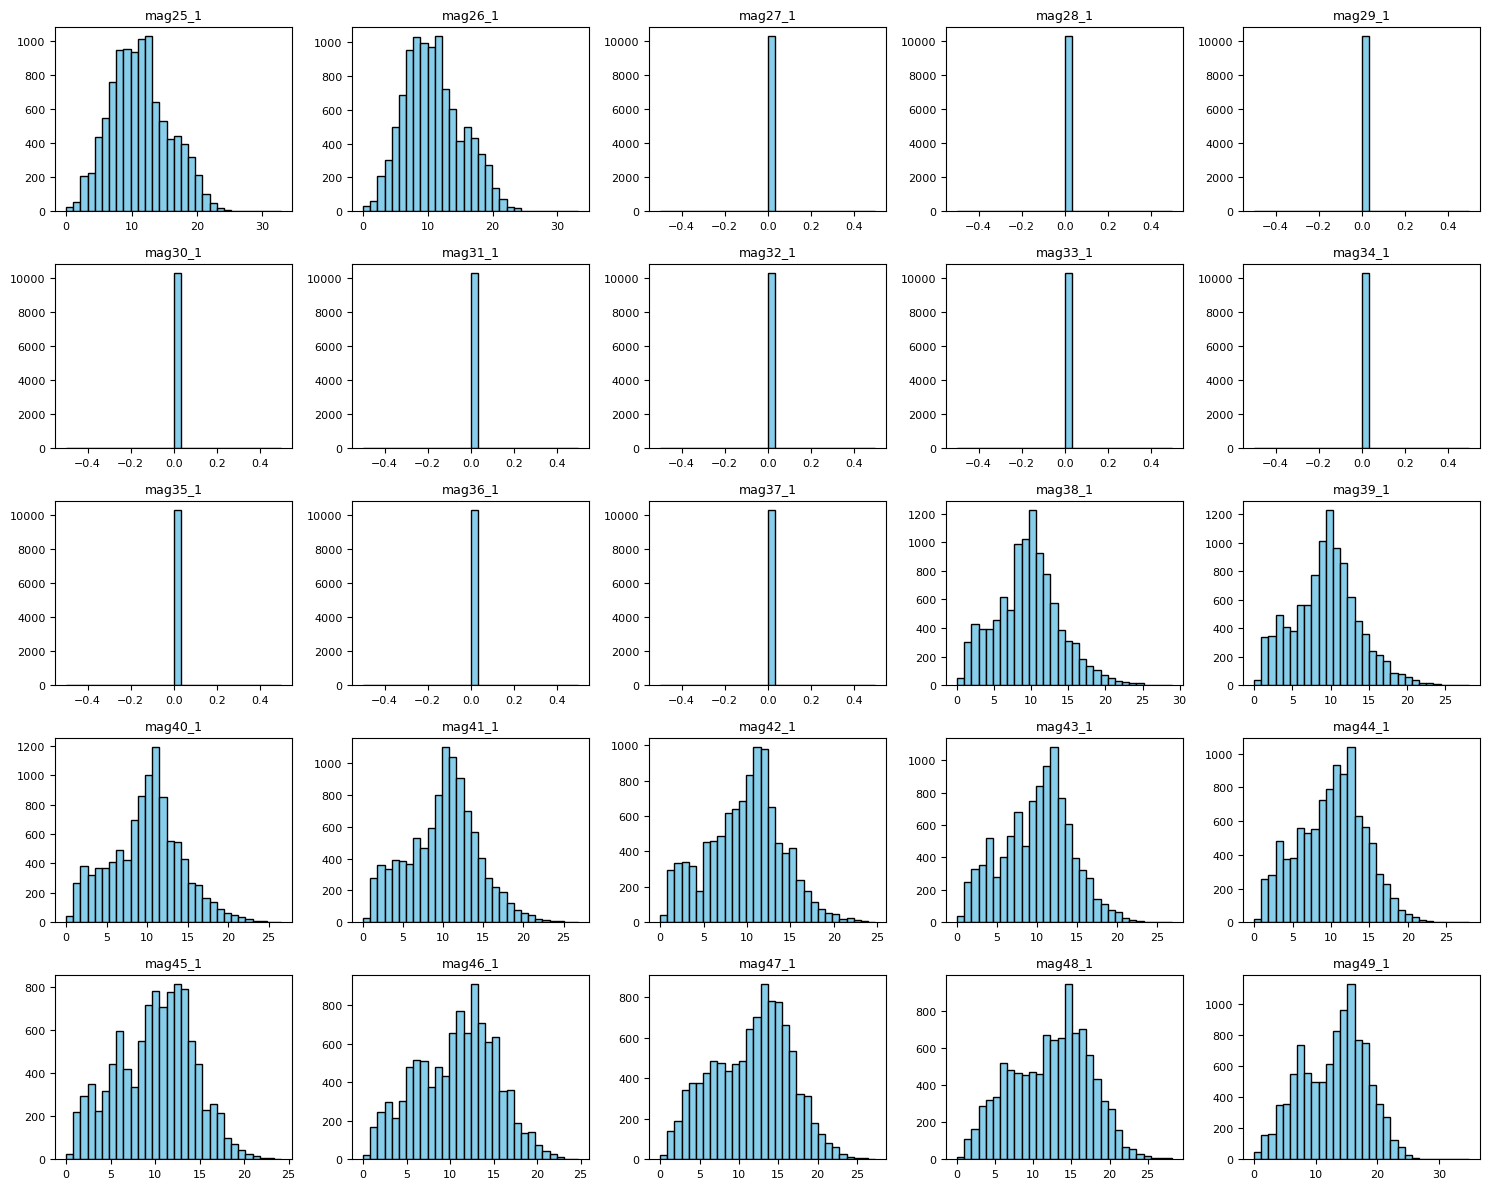

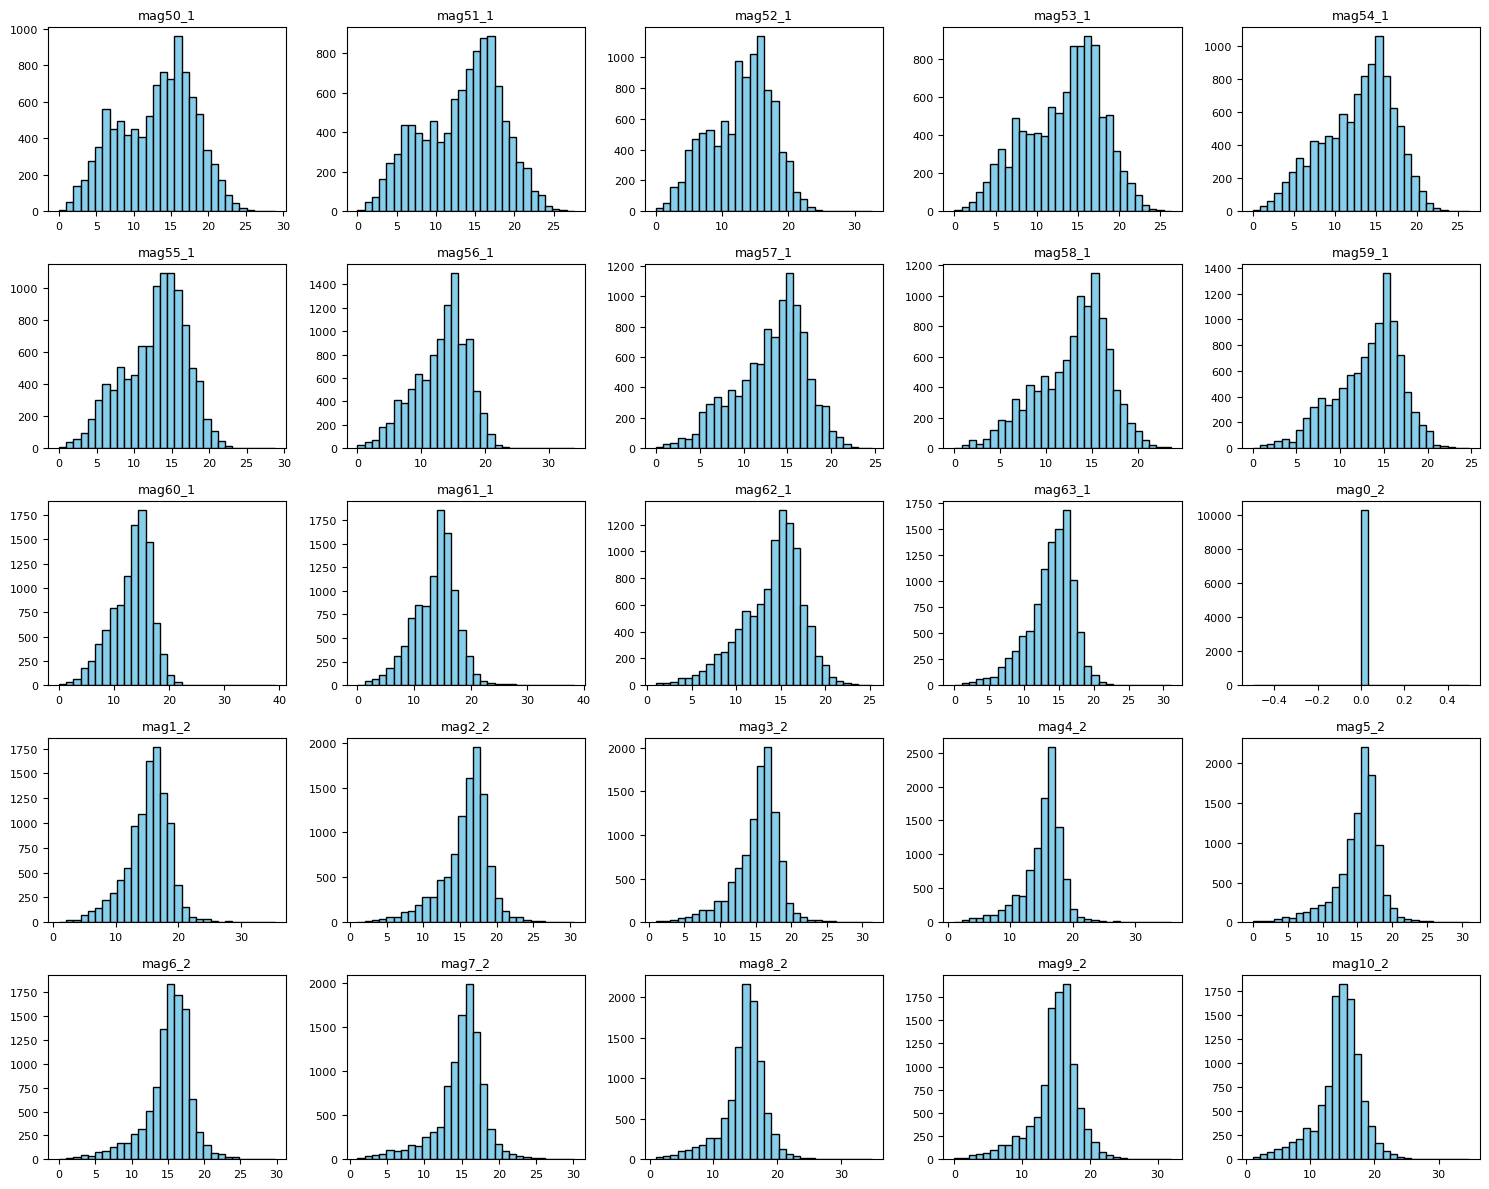

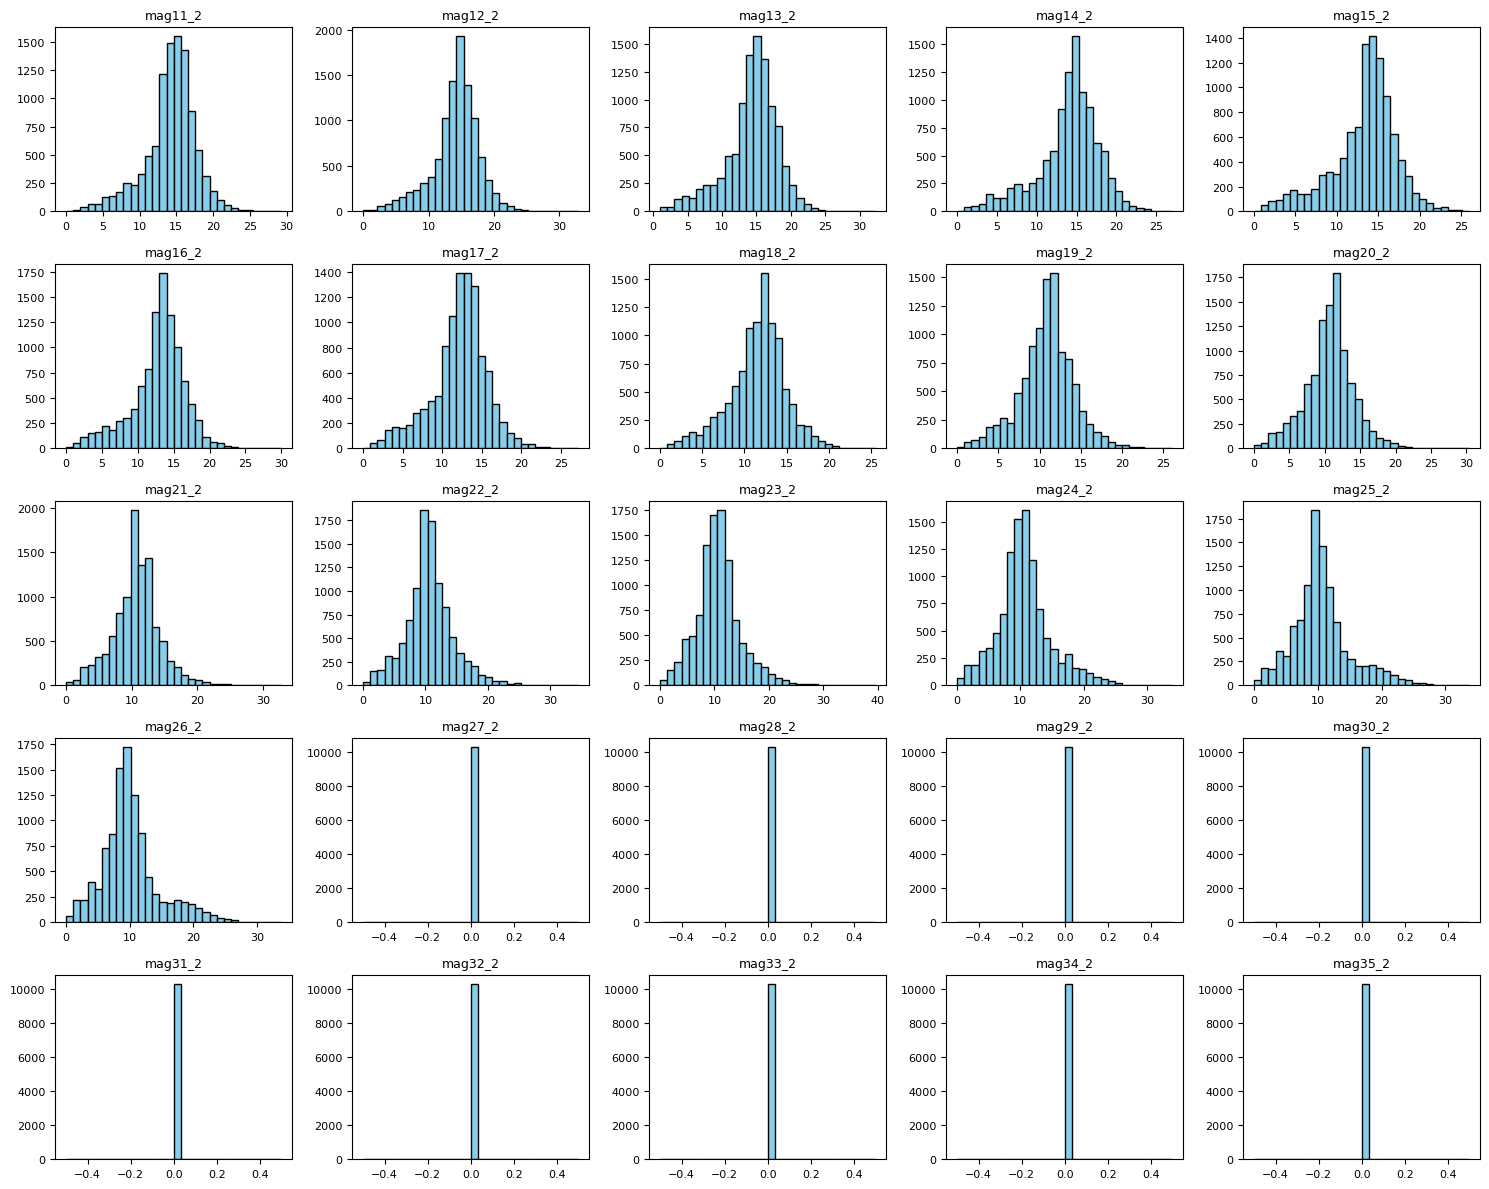

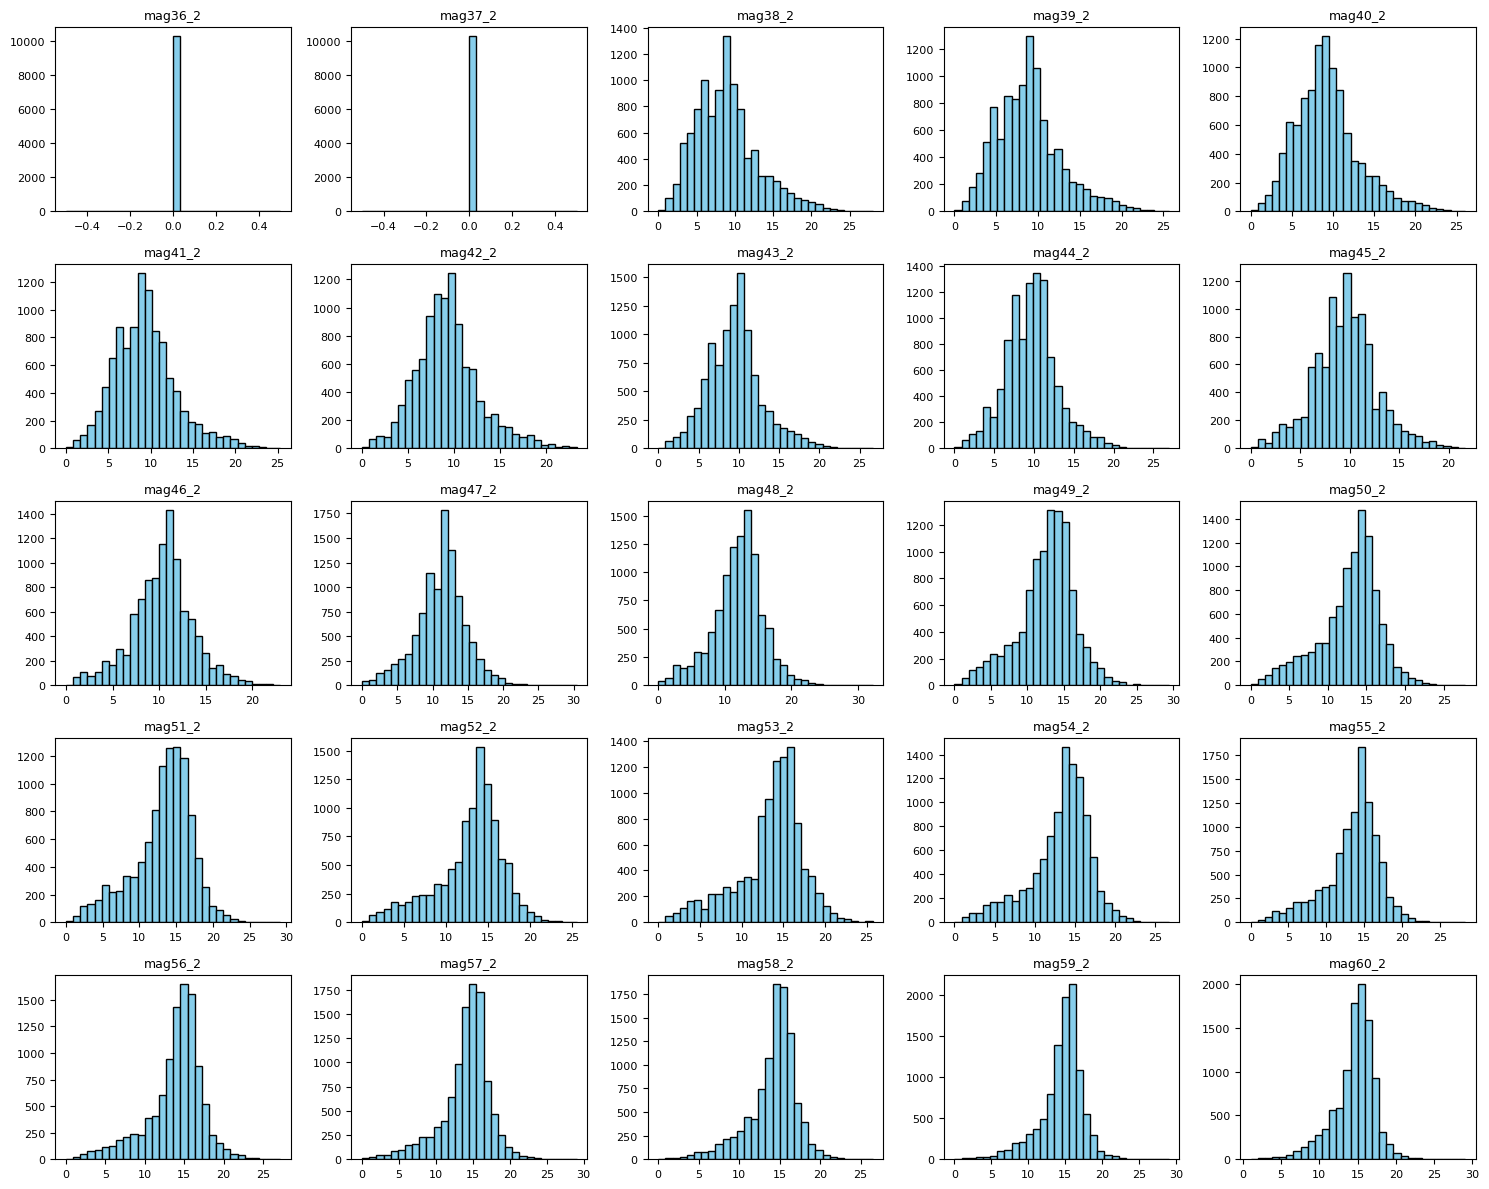

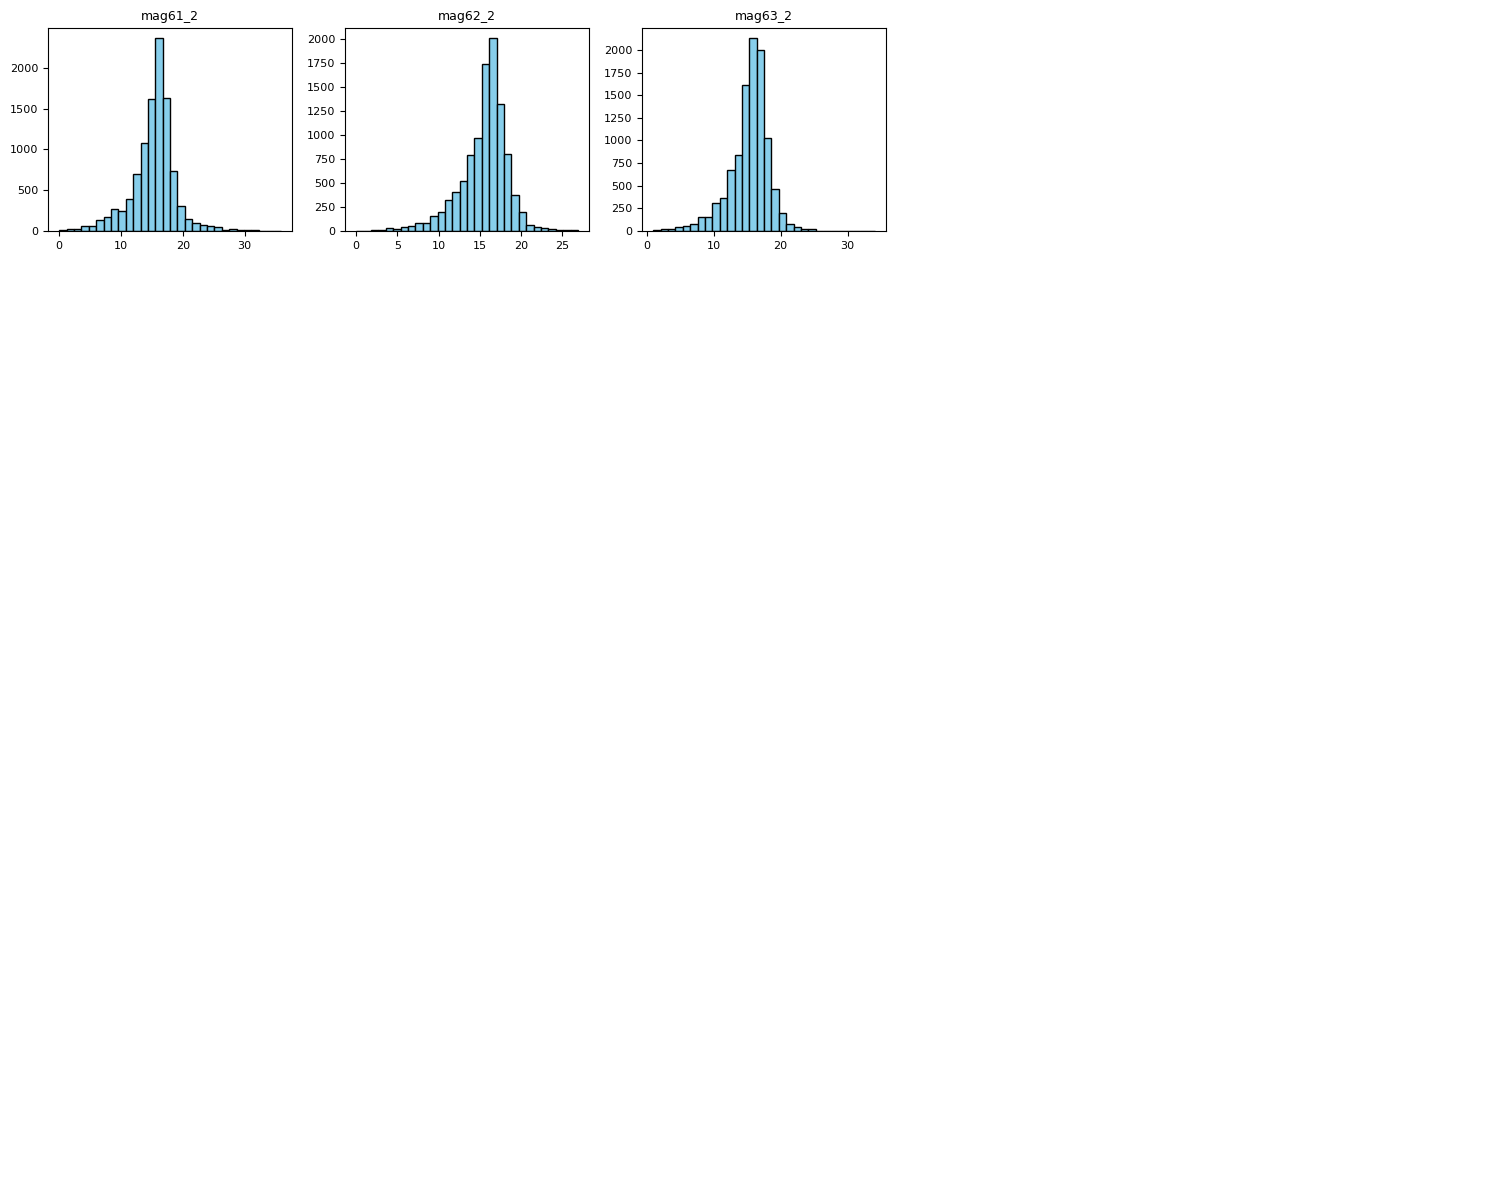

In [53]:
import matplotlib.pyplot as plt
import math

# 1. Identificar todas las columnas de magnitud (asumiendo que las llamaste 'amp...')
cols_magnitud = [f'mag{n}_{ant}' for ant in [1, 2] for n in range(64)]

# 2. Configuración de la cuadrícula
n_cols_grid = 5
n_rows_grid = 5
fotos_por_pagina = n_cols_grid * n_rows_grid

# 3. Bucle para mostrar de 25 en 25
for i in range(0, len(cols_magnitud), fotos_por_pagina):
    # Seleccionamos el bloque de 25 columnas
    bloque = cols_magnitud[i : i + fotos_por_pagina]
    
    # Creamos la figura
    fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 12))
    axes = axes.flatten() # Aplanar para iterar fácilmente
    
    for j, col in enumerate(bloque):
        # Dibujar histograma en el subgráfico correspondiente
        axes[j].hist(X_train[col], bins=30, color='skyblue', edgecolor='black')
        axes[j].set_title(col, fontsize=9)
        axes[j].tick_params(labelsize=8)
    
    # Ocultar ejes vacíos si el último bloque tiene menos de 25
    for k in range(len(bloque), fotos_por_pagina):
        axes[k].axis('off')
    
    plt.tight_layout()
    plt.show()

In [54]:
print(X_train_filtered.shape, y_train_filtered.shape)

(10045, 132) (10045,)


Eliminamos todas las magnitudes donde todo vale 0 (No aportan información)

In [55]:
const_col = [col for col in X_train.columns if X_train[col].nunique() <= 1]

print(f"Columnas eliminadas: {const_col}")
X_train_filtered = X_train_filtered.drop(columns=const_col)
X_test_nolabels = X_test_nolabels.drop(columns=const_col)
X_test = X_test.drop(columns=const_col)

Columnas eliminadas: ['mag0_1', 'mag27_1', 'mag28_1', 'mag29_1', 'mag30_1', 'mag31_1', 'mag32_1', 'mag33_1', 'mag34_1', 'mag35_1', 'mag36_1', 'mag37_1', 'mag0_2', 'mag27_2', 'mag28_2', 'mag29_2', 'mag30_2', 'mag31_2', 'mag32_2', 'mag33_2', 'mag34_2', 'mag35_2', 'mag36_2', 'mag37_2']


In [56]:
X_train_filtered.shape, y_train_filtered.shape

((10045, 108), (10045,))

# NORMALIZACIÓN DE LOS DATOS

MODELOS COMO KNN MISMO ESCALADO PARA HACER BIEN LOS CÁLCULOS DE LA DISTANCIA (NO DAR MÁS PESO A NINGUNA FEATURE)

Magnitudes (CSI) aprox 100: RobustScaler o StandardScaler
Por qué: El RobustScaler es ideal si detectas que hay valores extremos (outliers) que "estiran" mucho el histograma hacia la derecha, ya que utiliza la mediana y el rango intercuartílico en lugar de la media. Si después de limpiar los outliers las distribuciones parecen más estables, el StandardScaler (media 0, varianza 1) funcionará perfectamente para modelos como SVM o Redes Neuronales.

aoa: StandardScaler
Por qué: Al ser una distribución tan simétrica y similar a una Normal, el StandardScaler es el método más eficiente para centrarla y reducir su escala sin perder la relación angular que representa

rssi1 y rssi2: MinMaxScaler (rango 0 a 1) o StandardScaler
Por qué: El MinMaxScaler es muy útil aquí para transformar esos valores negativos a un rango positivo fácil de procesar para cualquier modelo. Sin embargo, si vas a usar un modelo de distancias como KNN, asegúrate de usar el mismo escalado que en las magnitudes para que el RSSI no pierda peso.

seq_ctrl: No escalar o eliminar.
Por qué: Según la guía, seq_ctrl es solo un número de secuencia. Si decides incluirlo, usa un escalado robusto, pero ten en cuenta que en problemas de localización física, el número de secuencia suele ser ruido que no ayuda a predecir la posición a menos que haya un sesgo temporal en la captura.


## CSI:

In [57]:
features = ['seq_ctrl', 'aoa', 'rssi1', 'rssi2']
col_magnitud = [col for col in X_train_filtered.columns if col.startswith('mag')]

scaler = preprocessing.RobustScaler()

X_train_filtered[col_magnitud] = scaler.fit_transform(X_train_filtered[col_magnitud])
X_test[col_magnitud] = scaler.transform(X_test[col_magnitud])
X_test_nolabels[col_magnitud] = scaler.transform(X_test_nolabels[col_magnitud])

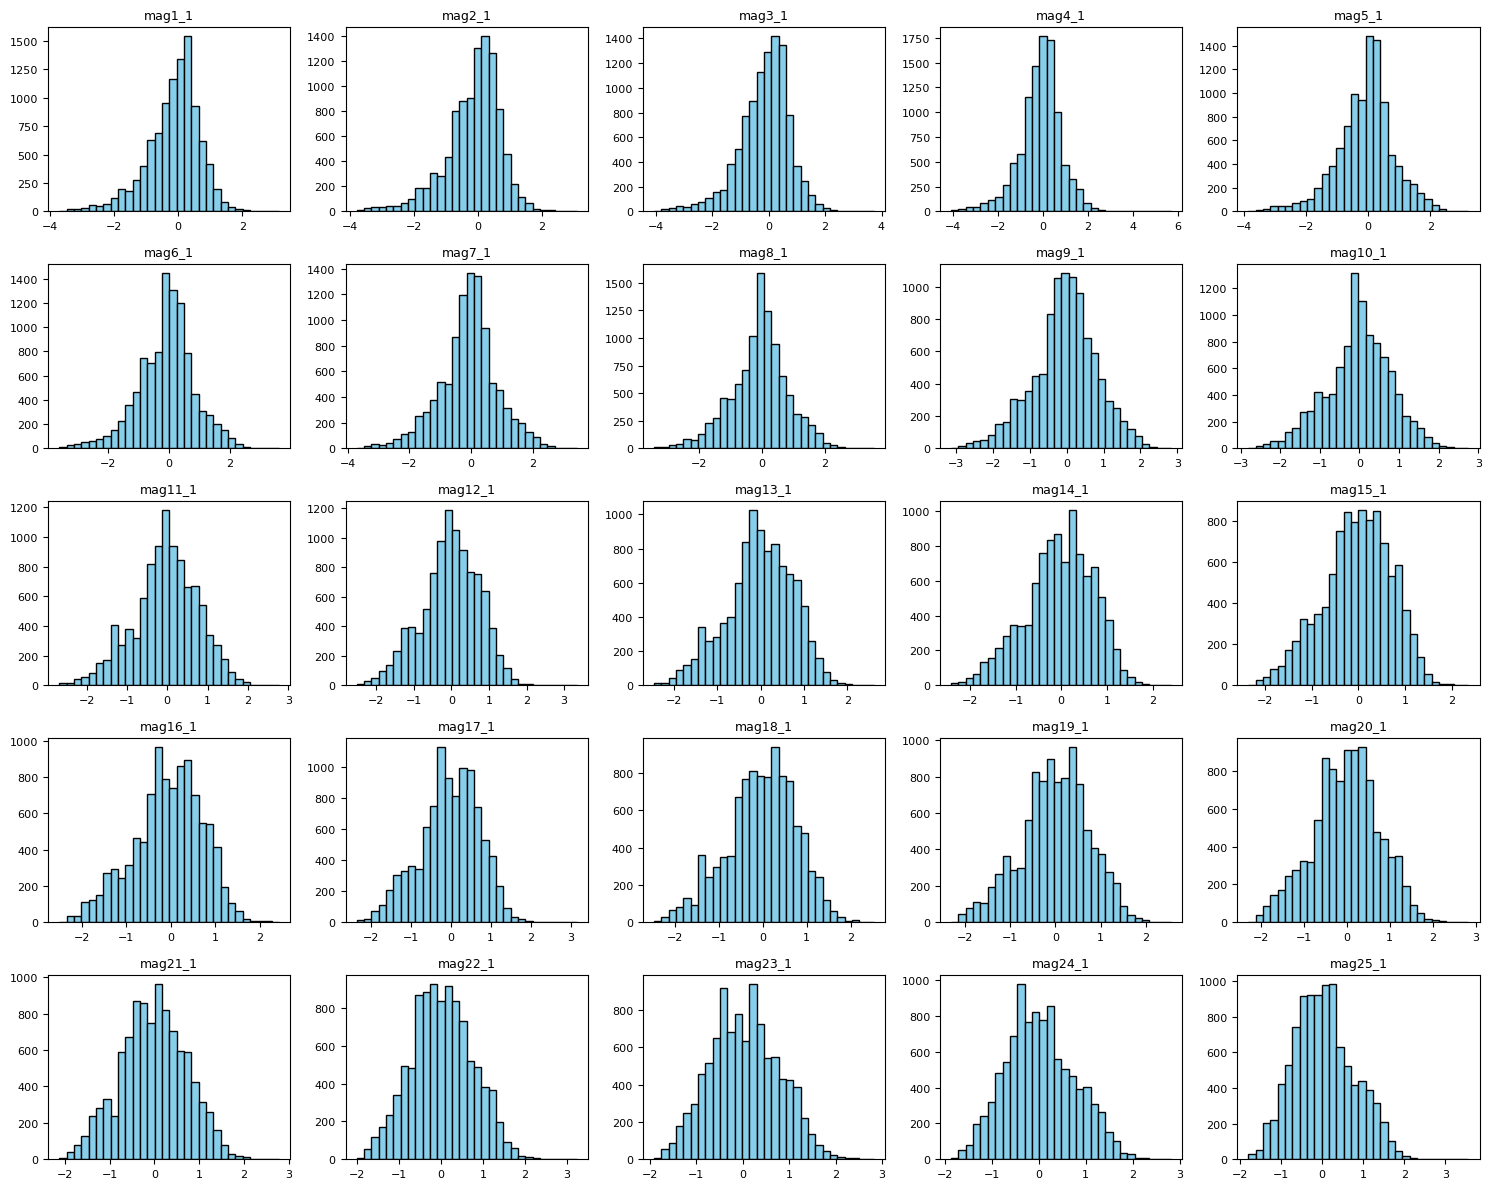

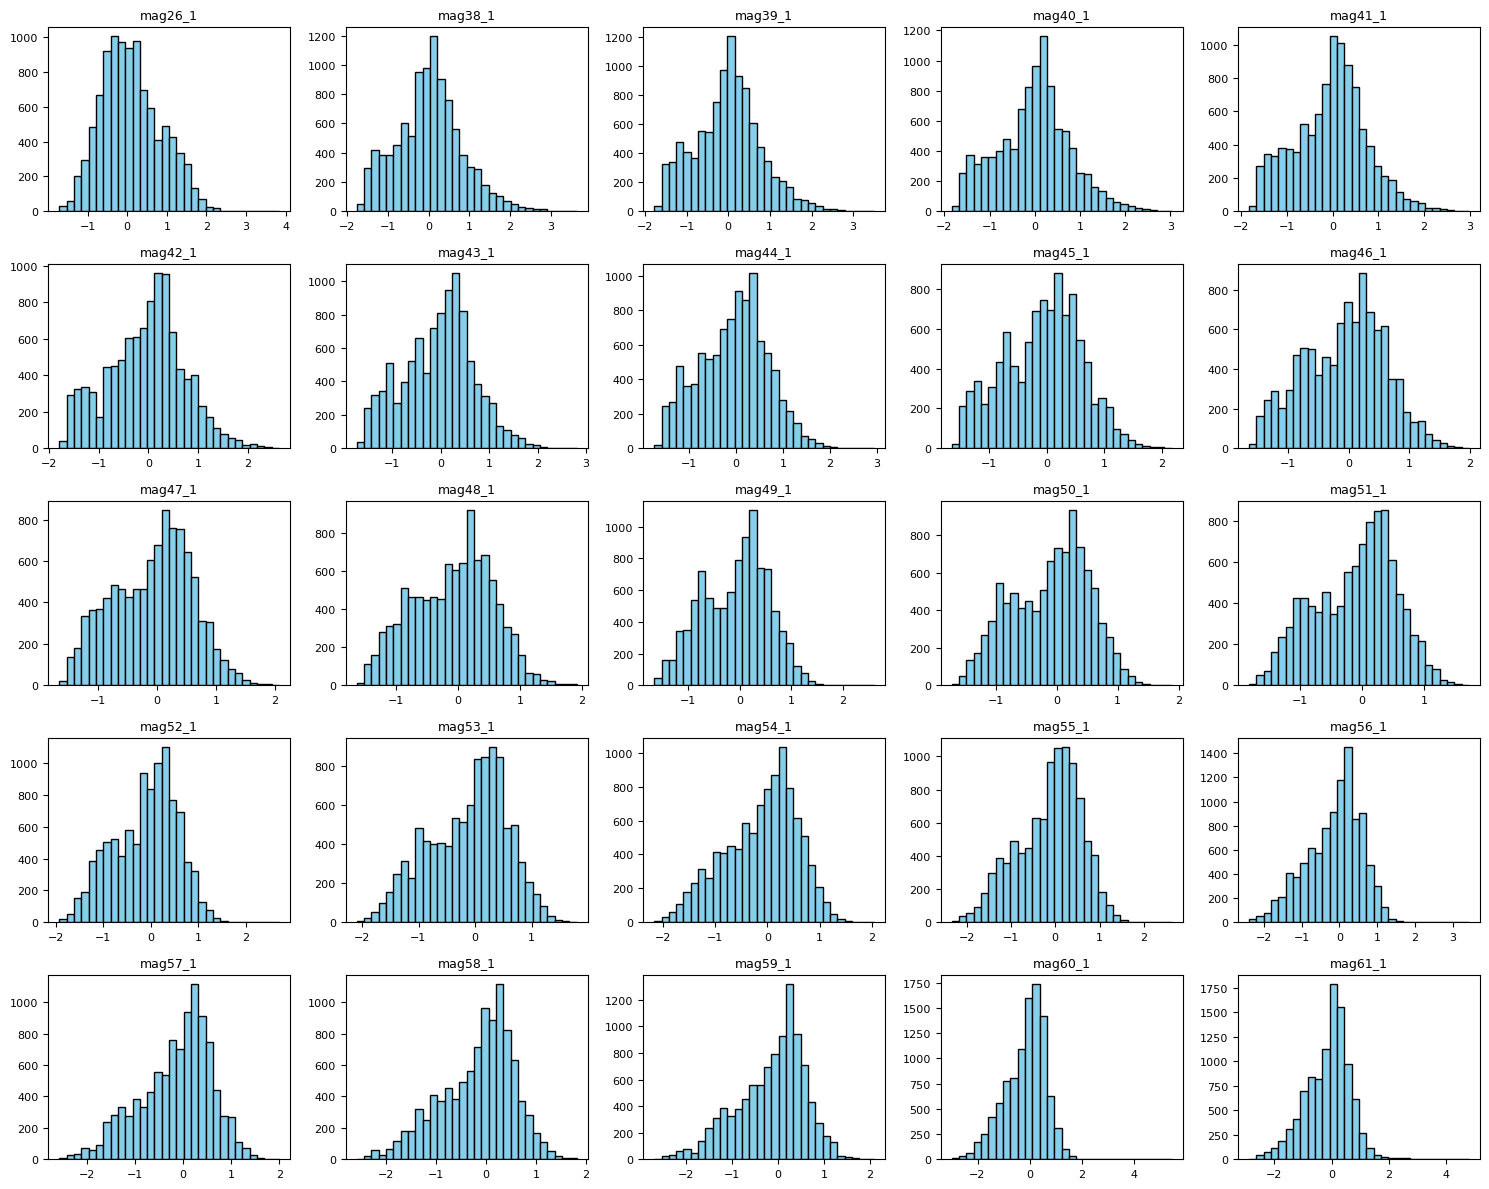

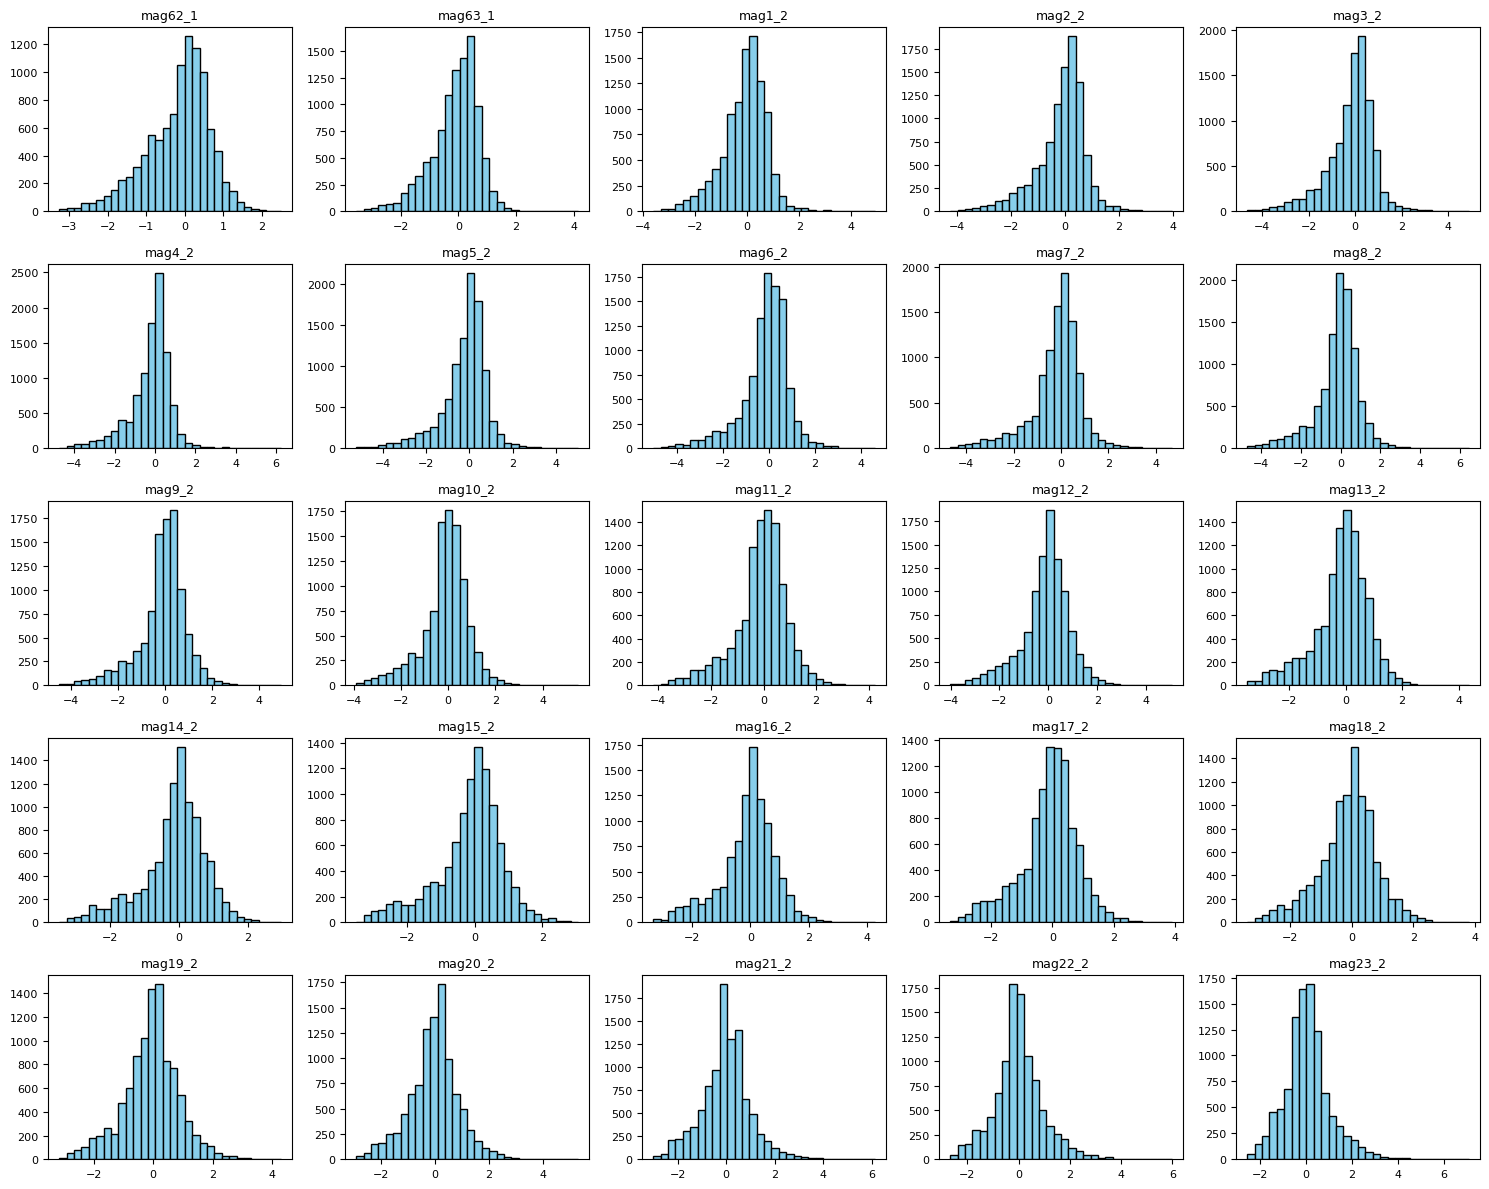

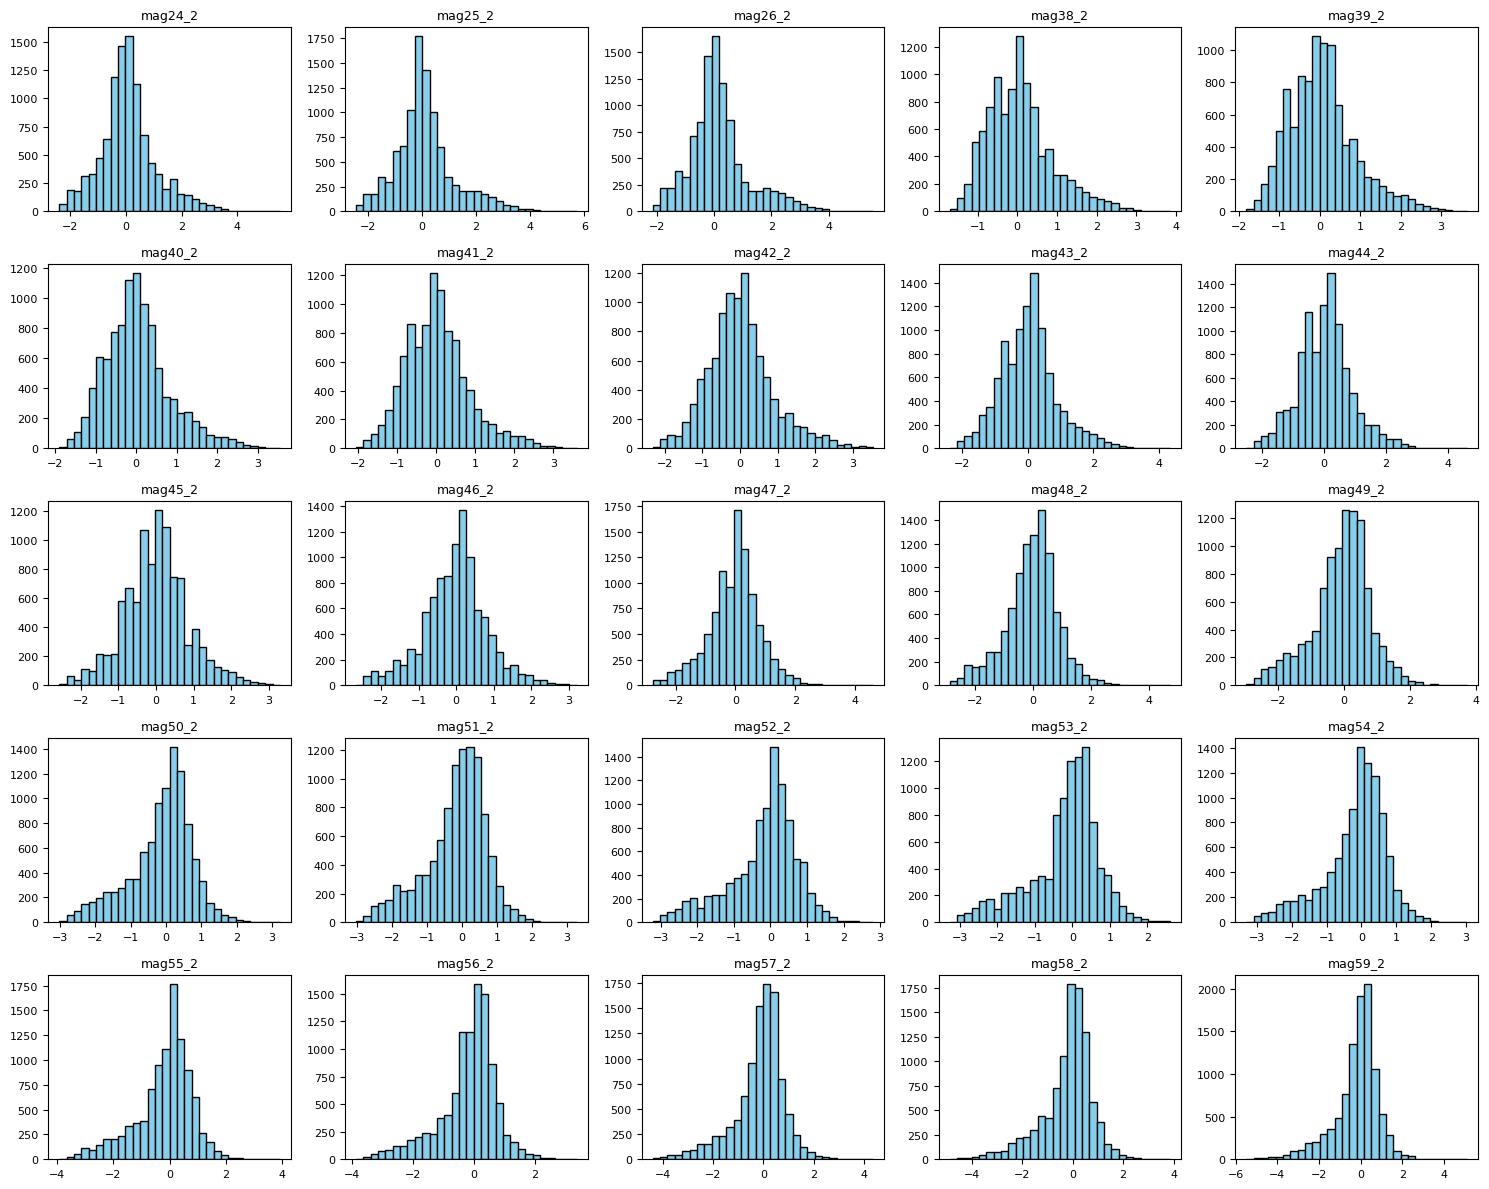

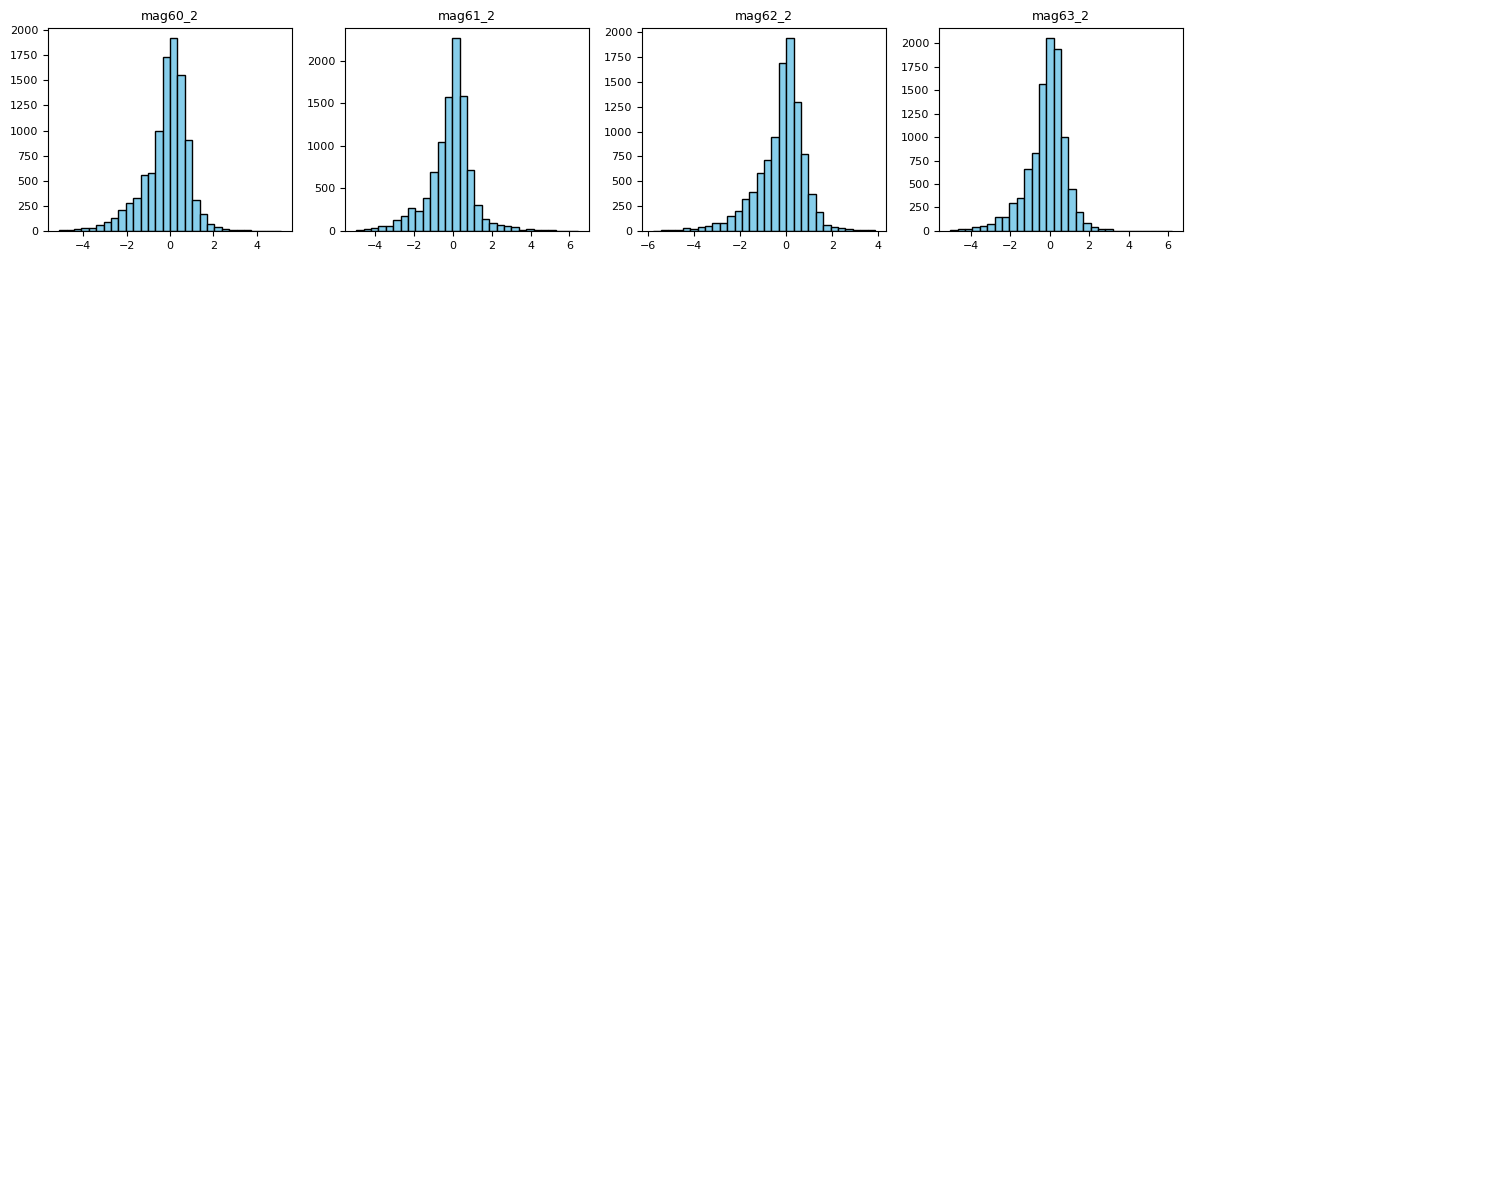

In [58]:
# 1. Identificar todas las columnas de magnitud (asumiendo que las llamaste 'amp...')
cols_magnitud = [col for col in X_train_filtered.columns if col.startswith('mag')]

# 2. Configuración de la cuadrícula
n_cols_grid = 5
n_rows_grid = 5
fotos_por_pagina = n_cols_grid * n_rows_grid

# 3. Bucle para mostrar de 25 en 25
for i in range(0, len(cols_magnitud), fotos_por_pagina):
    # Seleccionamos el bloque de 25 columnas
    bloque = cols_magnitud[i : i + fotos_por_pagina]
    
    # Creamos la figura
    fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 12))
    axes = axes.flatten() # Aplanar para iterar fácilmente
    
    for j, col in enumerate(bloque):
        # Dibujar histograma en el subgráfico correspondiente
        axes[j].hist(X_train_filtered[col], bins=30, color='skyblue', edgecolor='black')
        axes[j].set_title(col, fontsize=9)
        axes[j].tick_params(labelsize=8)
    
    # Ocultar ejes vacíos si el último bloque tiene menos de 25
    for k in range(len(bloque), fotos_por_pagina):
        axes[k].axis('off')
    
    plt.tight_layout()
    plt.show()

## aoa

In [59]:
scaler = preprocessing.StandardScaler()
X_train_filtered["aoa"] = scaler.fit_transform(X_train_filtered[["aoa"]])
X_test["aoa"] = scaler.transform(X_test[["aoa"]])
X_test_nolabels["aoa"] = scaler.transform(X_test_nolabels[["aoa"]])

array([<Axes: title={'center': 'aoa'}>], dtype=object)

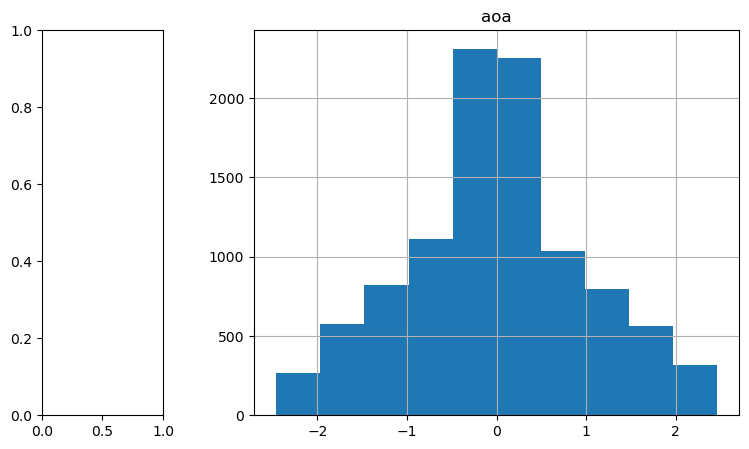

In [60]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.hist(column='aoa', ax=axes[1])

## rssi1 y rssi2:

In [61]:
scaler = preprocessing.StandardScaler()
X_train_filtered[["rssi1","rssi2"]] = scaler.fit_transform(X_train_filtered[["rssi1","rssi2"]])
X_test[["rssi1","rssi2"]] = scaler.transform(X_test[["rssi1","rssi2"]])
X_test_nolabels[["rssi1","rssi2"]] = scaler.transform(X_test_nolabels[["rssi1","rssi2"]])

array([<Axes: title={'center': 'rssi1'}>], dtype=object)

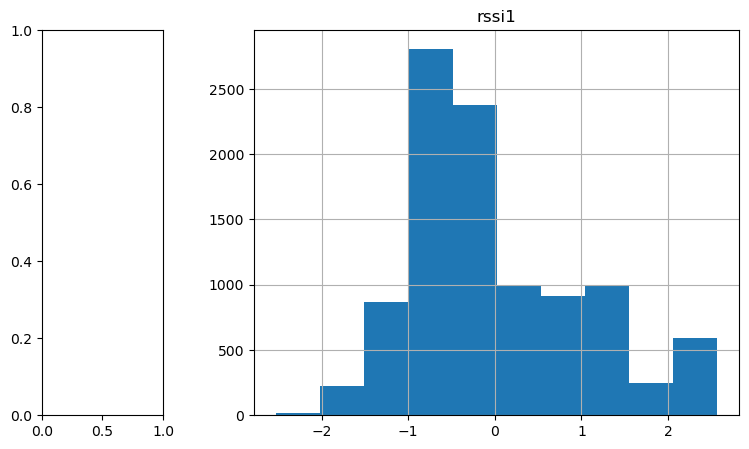

In [62]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.hist(column='rssi1', ax=axes[1])

array([<Axes: title={'center': 'rssi2'}>], dtype=object)

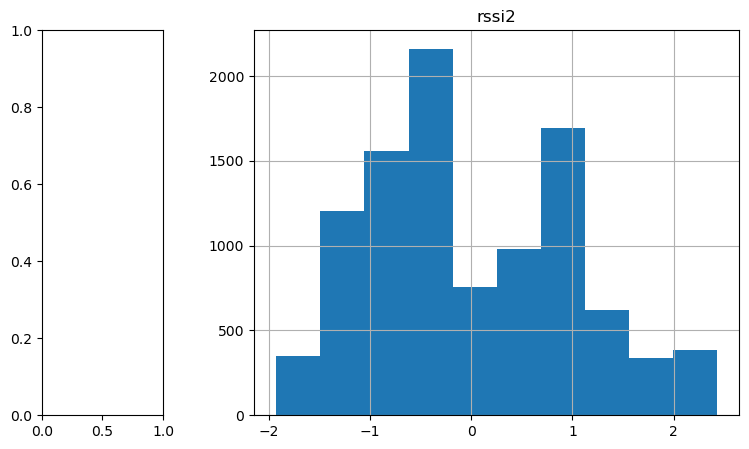

In [63]:
fig, axes= plt.subplots(1,2, gridspec_kw={'width_ratios': [1, 4]}, figsize=(9,5))
X_train_filtered.hist(column='rssi2', ax=axes[1])

In [64]:
X_train_filtered.shape, y_train_filtered.shape

((10045, 108), (10045,))

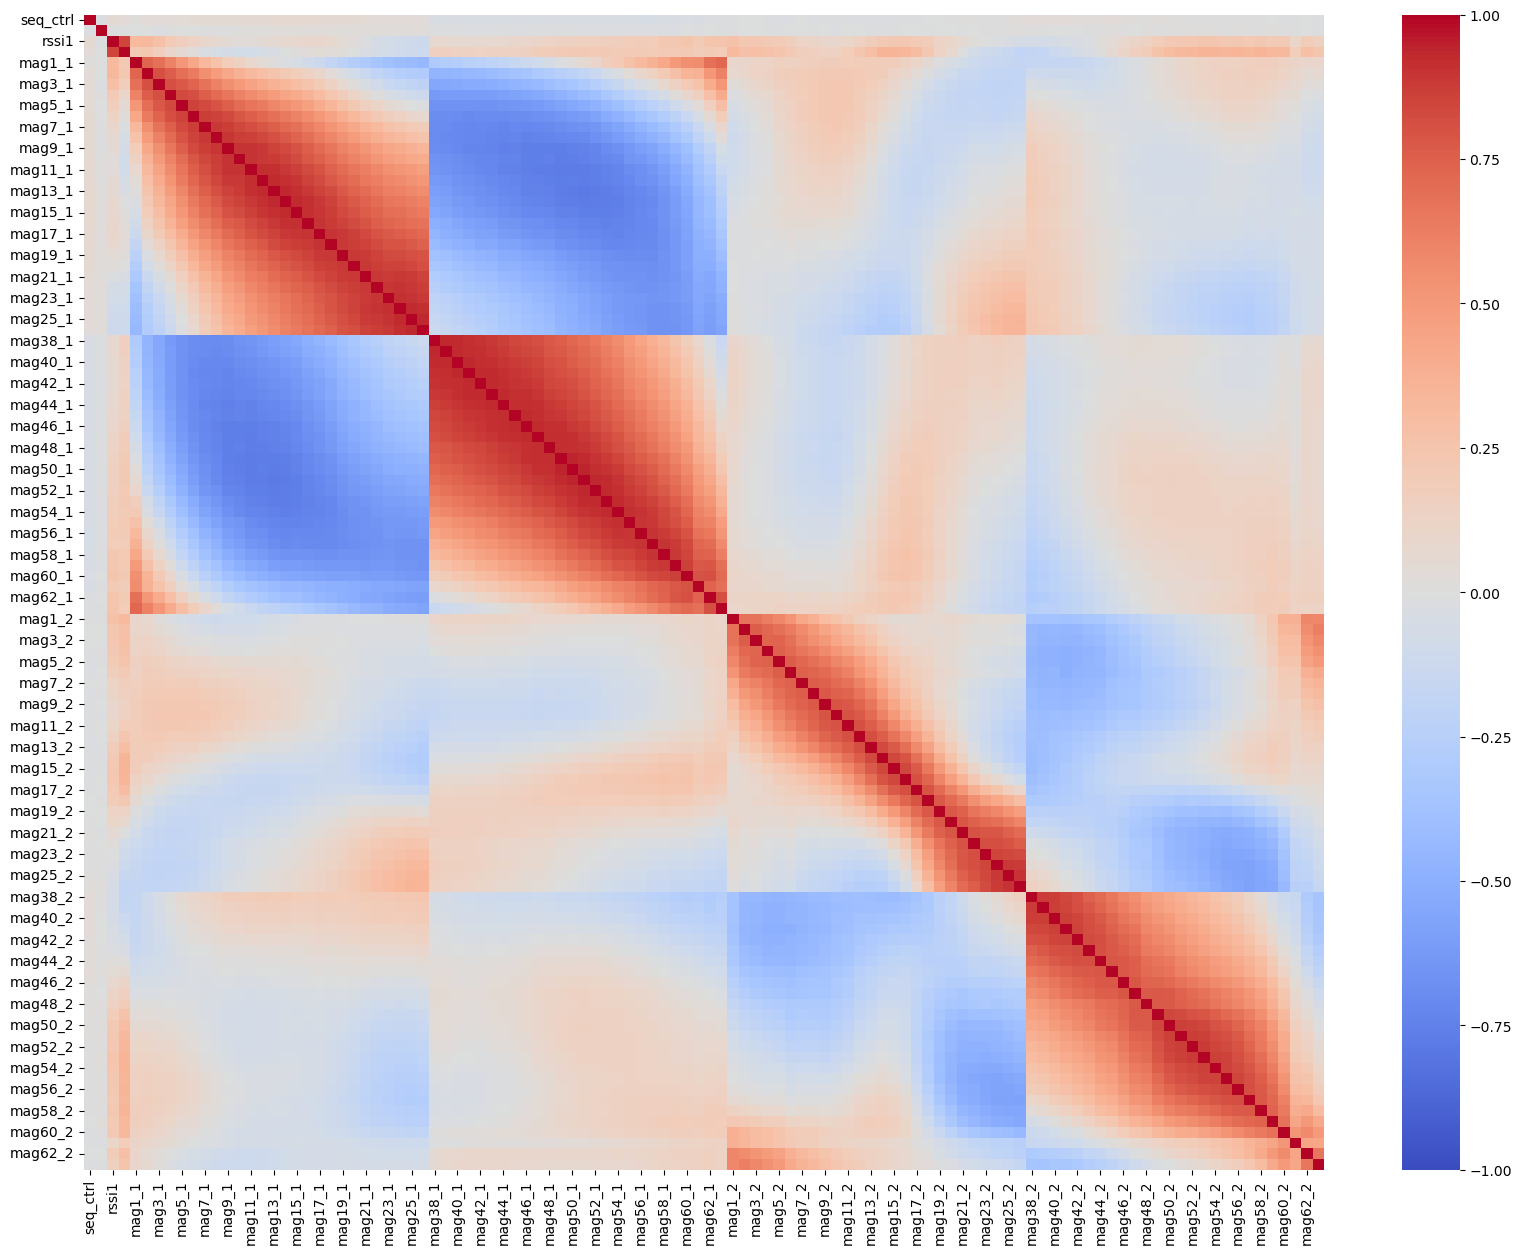

In [65]:
import seaborn

matriz_corr = X_train_filtered.corr()
plt.figure(figsize=(20, 15))
seaborn.heatmap(matriz_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

c:\Users\dijor\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\dijor\anaconda3\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


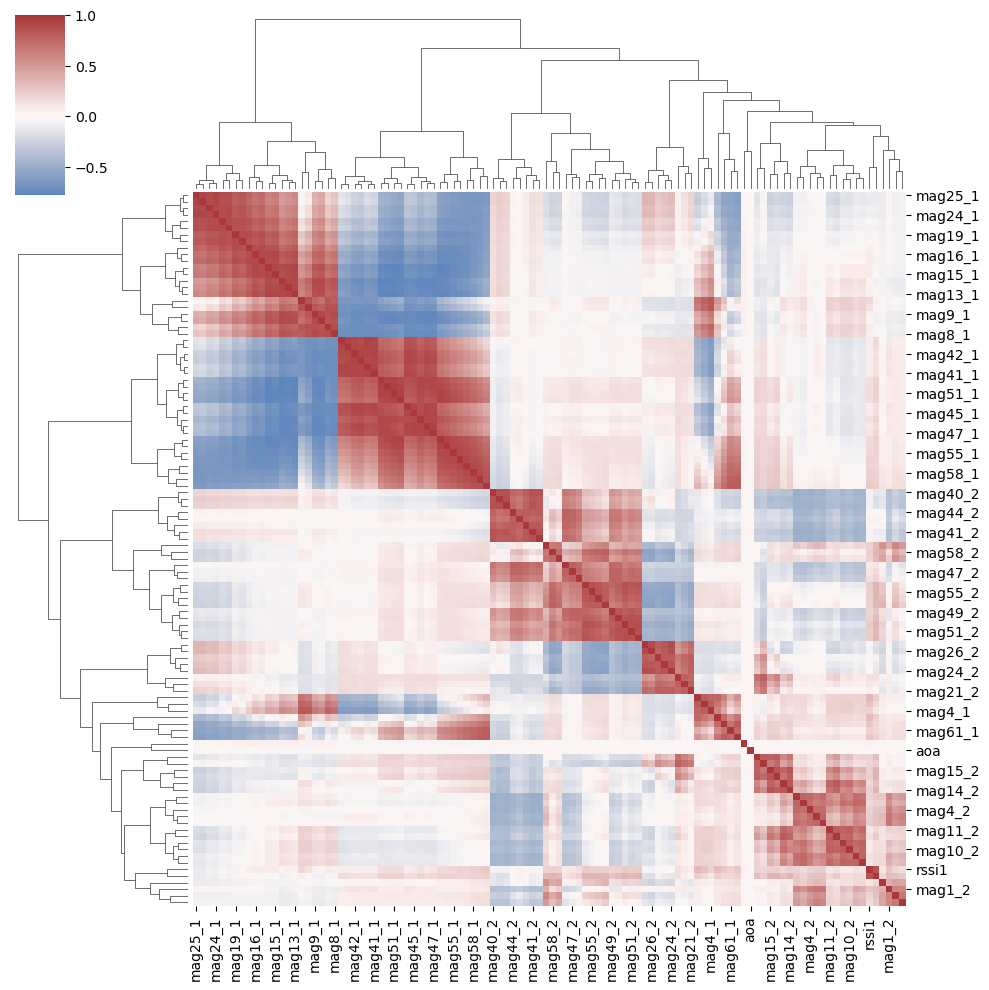

In [66]:
seaborn.clustermap(X_train_filtered.corr(), annot=False, cmap='vlag', center=0)
plt.show()

In [67]:
corr_seq_ctrl = matriz_corr['seq_ctrl'].sort_values(ascending=False)
print(corr_seq_ctrl)

seq_ctrl    1.000
mag16_1     0.067
mag14_1     0.064
mag13_1     0.063
mag15_1     0.063
            ...  
mag54_1    -0.045
mag52_1    -0.045
mag55_1    -0.045
mag56_1    -0.048
mag57_1    -0.048
Name: seq_ctrl, Length: 108, dtype: float64


In [68]:
corr_aoa = matriz_corr['aoa'].sort_values(ascending=False)
print(corr_aoa)

aoa         1.000
mag17_1     0.025
mag25_1     0.023
mag16_1     0.022
mag14_1     0.022
            ...  
mag55_1    -0.020
mag56_1    -0.020
mag51_1    -0.020
mag54_1    -0.022
seq_ctrl   -0.022
Name: aoa, Length: 108, dtype: float64


In [69]:
corr_rssi1 = matriz_corr['rssi1'].sort_values(ascending=False)
print(corr_rssi1)

rssi1      1.000
rssi2      0.848
mag2_1     0.328
mag1_1     0.318
mag3_1     0.277
           ...  
mag39_2   -0.073
mag23_1   -0.077
mag24_1   -0.089
mag25_1   -0.105
mag26_1   -0.119
Name: rssi1, Length: 108, dtype: float64


In [70]:
corr_rssi2 = matriz_corr['rssi2'].sort_values(ascending=False)
print(corr_rssi2)

rssi2      1.000
rssi1      0.848
mag58_2    0.358
mag54_2    0.357
mag53_2    0.356
           ...  
mag40_2   -0.130
mag25_2   -0.156
mag39_2   -0.166
mag38_2   -0.178
mag26_2   -0.182
Name: rssi2, Length: 108, dtype: float64



seq_ctrl poco correlacionada con las otras features. (la quitamos?)
aoa poco correlacionada con las otras features.
rssi1 y rssi2 muy correlacionadas y tienen correlación (negativa y positiva) con las diferentes magnitudes.

In [71]:
print(X_train_filtered.shape, y_train_filtered.shape)

X_train_filtered.drop(columns=['seq_ctrl'], inplace=True)
X_test.drop(columns=['seq_ctrl'], inplace=True)
X_test_nolabels.drop(columns=['seq_ctrl'], inplace=True)


(10045, 108) (10045,)


In [72]:
X_train_filtered.to_csv('../data/processed/train_iqr_features_scaling.csv', index=False)
X_test.to_csv('../data/processed/test_iqr_features_scaling.csv', index=False)

y_train_filtered.to_csv('../data/processed/y_train_iqr_features_scaling.csv', index=False)
y_test.to_csv('../data/processed/y_test_iqr_features_scaling.csv', index=False)

X_test_nolabels.to_csv('../data/processed/test_nolabels_iqr_features_scaling.csv', index=False)
